CELL 1 - LOAD DATA

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


CELL 2 — FEATURE ENGINEERING

In [2]:
# Pilih fitur yang relevan berdasarkan EDA
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'

df_model = df[features + [target]].copy()

# Handle missing values — Age diisi median
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

# Encode Sex: male=0, female=1
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

df_model.isnull().sum()  # verifikasi tidak ada missing values

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Survived    0
dtype: int64

CELL 3 — TRAIN/TEST SPLIT

In [3]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (712, 6)
Test set: (179, 6)


CELL 4 — TRAIN MODEL

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


CELL 5 — EVALUASI

Accuracy: 0.8101

               precision    recall  f1-score   support

Tidak Selamat       0.81      0.88      0.84       105
      Selamat       0.80      0.72      0.76        74

     accuracy                           0.81       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.81      0.81       179



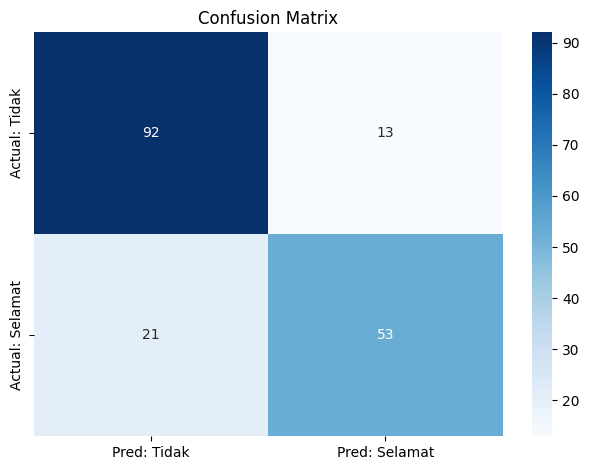

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Tidak Selamat', 'Selamat']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Tidak', 'Pred: Selamat'],
            yticklabels=['Actual: Tidak', 'Actual: Selamat'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

CELL 6 — SAVE MODEL

In [6]:
import pickle

with open('../model/titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to model/titanic_model.pkl")

Model saved to model/titanic_model.pkl
